# CORINE mapping and data preperation

In [1]:
import os
import json
from pathlib import Path
from datetime import datetime

import numpy as np
import zipfile
import matplotlib.pyplot as plt
import rasterio
from rasterio.warp import calculate_default_transform, reproject, Resampling
from rasterio.crs import CRS
from rasterio.enums import Resampling

## CORINE mapping dics

In [2]:
# CORINE class descriptions (simplified codes 1-44 used in raster)
CORINE_CLASSES = {
    # Artificial surfaces (1-11)
    1: "Continuous urban fabric",
    2: "Discontinuous urban fabric",
    3: "Industrial or commercial units",
    4: "Road and rail networks",
    5: "Port areas",
    6: "Airports",
    7: "Mineral extraction sites",
    8: "Dump sites",
    9: "Construction sites",
    10: "Green urban areas",
    11: "Sport and leisure facilities",
    
    # Agricultural areas (12-22)
    12: "Non-irrigated arable land",
    13: "Permanently irrigated land",
    14: "Rice fields",
    15: "Vineyards",
    16: "Fruit trees and berry plantations",
    17: "Olive groves",
    18: "Pastures",
    19: "Annual crops with permanent crops",
    20: "Complex cultivation patterns",
    21: "Agriculture with natural vegetation",
    22: "Agro-forestry areas",
    
    # Forest and semi-natural areas (23-34)
    23: "Broad-leaved forest",
    24: "Coniferous forest",
    25: "Mixed forest",
    26: "Natural grasslands",
    27: "Moors and heathland",
    28: "Sclerophyllous vegetation",
    29: "Transitional woodland-shrub",
    30: "Beaches, dunes, sands",
    31: "Bare rocks",
    32: "Sparsely vegetated areas",
    33: "Burnt areas",
    34: "Glaciers and perpetual snow",
    
    # Wetlands (35-39)
    35: "Inland marshes",
    36: "Peat bogs",
    37: "Salt marshes",
    38: "Salines",
    39: "Intertidal flats",
    
    # Water bodies (40-44)
    40: "Water courses",
    41: "Water bodies",
    42: "Coastal lagoons",
    43: "Estuaries",
    44: "Sea and ocean",
    
    48: "No data"
}

# Color mapping for visualization
CORINE_COLORS = {
    1: '#E6004D', 2: '#FF0000', 3: '#CC4DF2', 4: '#CC0000', 5: '#E6CCCC',
    6: '#E6CCE6', 7: '#A600CC', 8: '#A64DCC', 9: '#FF4DFF', 10: '#FFA6FF',
    11: '#FFE6FF', 12: '#FFFFA8', 13: '#FFFF00', 14: '#E6E600', 15: '#E68000',
    16: '#F2A64D', 17: '#E6A600', 18: '#E6E64D', 19: '#FFE6A6', 20: '#FFE64D',
    21: '#E6CC4D', 22: '#F2CCA6', 23: '#80FF00', 24: '#00A600', 25: '#4DFF00',
    26: '#CCF24D', 27: '#A6FF80', 28: '#A6E64D', 29: '#A6F200', 30: '#E6E6E6',
    31: '#CCCCCC', 32: '#CCFFCC', 33: '#000000', 34: '#A6E6CC', 35: '#A6A6FF',
    36: '#4D4DFF', 37: '#CCCCFF', 38: '#E6E6FF', 39: '#A6A6E6', 40: '#00CCF2',
    41: '#80F2E6', 42: '#00FFA6', 43: '#A6FFE6', 44: '#E6F2FF'
}

## Processing Parameters

In [ ]:
user = "prokop1"

S2_DATA_DIR = f"/p/scratch/training2600/{user}/data/"

CORINE_PATH = "/p/scratch/training2600/CORINE/u2018_clc2018_v2020_20u1_raster100m/DATA/U2018_CLC2018_V2020_20u1.tif"

OUTPUT_DIR = f"/p/scratch/training2600/{user}/data/aligned_data"

TRAINING_DIR = f"/p/scratch/training2600/{user}/data/training_data"

RESULTS_DIR = f"/p/home/jusers/prokop1/jureca/project/{user}/results"

SKIP_EXISTING = True  # Skip tiles that already have output files

# --- Patch Extraction Parameters ---
PATCH_SIZE = 3       # Size in pixels (3 = 30m x 30m at 10m resolution)
STRIDE = None        # Stride for extraction (None = same as PATCH_SIZE, no overlap)
MAX_PATCHES = 40000  # Maximum patches per tile (increased to improve training quality)

# Options: 'minmax', 'zscore', 'percentile', 'none'
NORMALIZATION = 'percentile'

PERCENTILE_LOW = 2
PERCENTILE_HIGH = 98

## Function definitions

### Copied from 2.1

In [20]:
def find_s2_tiles(data_dir):
    """
    Find Sentinel-2 .SAFE directories to process.
    
    Parameters:
    -----------
    data_dir : str
        Directory containing .SAFE folders
    selection : str
        'all' to find all tiles, 'list' to use tile_list
    tile_list : list
        List of specific tile names to process
    
    Returns:
    --------
    list : List of Path objects for .SAFE directories
    """
    data_path = Path(data_dir)
    
    if not data_path.exists():
        print(f"❌ Data directory not found: {data_dir}")
        return []
    
    zip_files = list(data_path.glob("*.zip"))
    if zip_files:
        print(f"⚠ Found ZIP files in {data_dir}. Extracting them first...")
        for zip_file in zip_files:
            extract_sentinel2(zip_file, data_dir)
    tiles = sorted(data_path.glob("*.SAFE"))

    return tiles

def extract_sentinel2(zip_path, output_dir=None):
    """
    Extract a Sentinel-2 ZIP file to a SAFE directory.
    
    Parameters:
    -----------
    zip_path : str
        Path to the Sentinel-2 ZIP file
    output_dir : str, optional
        Directory to extract to. If None, extracts to same directory as ZIP.
    
    Returns:
    --------
    str : Path to extracted SAFE directory
    """    
    if output_dir is None:
        output_dir = os.path.dirname(zip_path)
    
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        # Get the SAFE directory name (first item in the archive)
        safe_dir = zip_ref.namelist()[0].split('/')[0]
        safe_path = os.path.join(output_dir, safe_dir)
        
        if os.path.exists(safe_path):
            print(f"  ⚠ Already extracted: {safe_dir}")
        else:
            zip_ref.extractall(output_dir)
            print(f"  ✓ Extracted to: {safe_path}")
    
    return safe_path

def stack_s2_bands(safe_path, output_path):
    """
    Stack Sentinel-2 bands (B02, B03, B04, B08) into a single GeoTIFF.
    
    Parameters:
    -----------
    safe_path : Path
        Path to .SAFE directory
    output_path : Path
        Output path for stacked GeoTIFF
    
    Returns:
    --------
    dict : Info about the stacked file (crs, bounds, etc.) or None on failure
    """
    bands = ['B02', 'B03', 'B04', 'B08']  # Blue, Green, Red, NIR
    resolution = '10m'
    
    try:
        # Find band files
        band_paths = {}
        for band_name in bands:
            pattern = f"**/R{resolution}/*_{band_name}_{resolution}.jp2"
            matches = list(safe_path.glob(pattern))
            if matches:
                band_paths[band_name] = matches[0]
            else:
                print(f"  ⚠ {band_name} not found")
                return None
        
        # Read first band for metadata
        with rasterio.open(band_paths['B02']) as src:
            profile = src.profile.copy()
            height, width = src.height, src.width
            crs = src.crs
            transform = src.transform
            bounds = src.bounds
        
        # Update profile for output
        profile.update(
            driver='GTiff',
            count=len(bands),
            dtype='uint16',
            compress='lzw',
            tiled=True,
            blockxsize=256,
            blockysize=256
        )
        
        # Create output and write bands
        with rasterio.open(output_path, 'w', **profile) as dst:
            for i, (band_name, band_path) in enumerate(band_paths.items(), start=1):
                with rasterio.open(band_path) as src:
                    data = src.read(1)
                    dst.write(data, i)
                    dst.set_band_description(i, band_name)
        
        return {
            'crs': crs,
            'width': width,
            'height': height,
            'transform': transform,
            'bounds': bounds,
            'bands': bands
        }
        
    except Exception as e:
        print(f"  ❌ Band stacking failed: {e}")
        import traceback
        traceback.print_exc()
        return None

def align_corine_to_s2(corine_path, s2_path, output_path):
    """
    Align CORINE raster to match Sentinel-2 tile geometry using rasterio.
    
    Parameters:
    -----------
    corine_path : Path
        Path to CORINE GeoTIFF
    s2_path : Path
        Path to stacked S2 GeoTIFF (reference)
    output_path : Path
        Output path for aligned CORINE
    
    Returns:
    --------
    bool : Success status
    """
    try:
        # Get S2 geometry (target)
        with rasterio.open(s2_path) as s2_src:
            dst_crs = s2_src.crs
            dst_transform = s2_src.transform
            dst_width = s2_src.width
            dst_height = s2_src.height
            dst_bounds = s2_src.bounds
        
        print(f"    Target CRS: {dst_crs}")
        print(f"    Target size: {dst_width} x {dst_height} pixels")
        print(f"    Target bounds: {dst_bounds}")
        
        # Open CORINE and reproject
        with rasterio.open(corine_path) as src:
            # Create output profile
            out_profile = src.profile.copy()
            out_profile.update(
                driver='GTiff',
                crs=dst_crs,
                transform=dst_transform,
                width=dst_width,
                height=dst_height,
                compress='lzw',
                tiled=True
            )
            
            # Create output raster
            with rasterio.open(output_path, 'w', **out_profile) as dst:
                # Reproject using nearest neighbor (for categorical data)
                reproject(
                    source=rasterio.band(src, 1),
                    destination=rasterio.band(dst, 1),
                    src_transform=src.transform,
                    src_crs=src.crs,
                    dst_transform=dst_transform,
                    dst_crs=dst_crs,
                    resampling=Resampling.nearest
                )
        
        return True
        
    except Exception as e:
        print(f"  ❌ CORINE alignment failed: {e}")
        import traceback
        traceback.print_exc()
        return False


def check_corine_coverage(corine_path):
    """
    Check if aligned CORINE has valid data.
    
    Returns:
    --------
    tuple : (has_valid_data, unique_classes, coverage_percent)
    """
    with rasterio.open(corine_path) as src:
        data = src.read(1)
    
    total_pixels = data.size
    valid_mask = (data >= 1) & (data <= 44)
    valid_pixels = np.sum(valid_mask)
    coverage_percent = (valid_pixels / total_pixels) * 100
    
    unique = np.unique(data[valid_mask])
    
    return len(unique) > 0, unique, coverage_percent

def process_tile_alignment(safe_path, corine_path, output_dir, skip_existing=True):
    """
    Process a single Sentinel-2 tile: stack bands and align CORINE.
    
    Returns:
    --------
    dict : Processing results
    """
    tile_name = safe_path.stem
    result = {
        'tile': tile_name,
        'status': 'unknown',
        's2_stacked': None,
        'corine_aligned': None,
        'crs': None,
        'n_classes': 0,
        'coverage_percent': 0
    }
    
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)
    
    # Output paths
    s2_stacked = output_dir / f"{tile_name}_stacked.tif"
    corine_aligned = output_dir / f"corine_aligned_{tile_name}.tif"
    
    # Check for existing output
    if skip_existing and s2_stacked.exists() and corine_aligned.exists():
        print(f"  ⏭ Skipping (outputs exist)")
        has_coverage, classes, coverage = check_corine_coverage(corine_aligned)
        result['status'] = 'skipped'
        result['s2_stacked'] = str(s2_stacked)
        result['corine_aligned'] = str(corine_aligned)
        result['n_classes'] = len(classes)
        result['coverage_percent'] = coverage
        return result
    
    # Step 1: Stack bands
    print(f"  📦 Stacking S2 bands...")
    stack_info = stack_s2_bands(safe_path, s2_stacked)
    if stack_info is None:
        result['status'] = 'failed_stacking'
        return result
    
    result['crs'] = str(stack_info['crs'])
    print(f"    Created: {s2_stacked.name}")
    print(f"    Size: {stack_info['width']} x {stack_info['height']} pixels")
    print(f"    CRS: {stack_info['crs']}")
    
    # Step 2: Align CORINE
    print(f"  🗺️ Aligning CORINE to S2 geometry...")
    if not align_corine_to_s2(corine_path, s2_stacked, corine_aligned):
        result['status'] = 'failed_alignment'
        return result
    
    # Step 3: Check coverage
    print(f"  🔍 Checking CORINE coverage...")
    has_coverage, classes, coverage = check_corine_coverage(corine_aligned)
    
    if not has_coverage:
        print(f"  ⚠ No valid CORINE data (tile outside coverage?)")
        result['status'] = 'no_coverage'
        return result
    
    result['status'] = 'success'
    result['s2_stacked'] = str(s2_stacked)
    result['corine_aligned'] = str(corine_aligned)
    result['n_classes'] = len(classes)
    result['coverage_percent'] = coverage
    
    print(f"    CORINE classes found: {len(classes)}")
    print(f"    Valid coverage: {coverage:.1f}%")
    
    return result

def visualize_alignment(s2_path, corine_path, title="Alignment Verification", save_path=None, is_show_plot=True):
    """
    Visualize the S2 image and aligned CORINE side by side.
    
    Parameters:
    -----------
    s2_path : str or Path
        Path to stacked S2 GeoTIFF
    corine_path : str or Path
        Path to aligned CORINE GeoTIFF
    title : str
        Plot title
    save_path : str or Path, optional
        Path to save the figure (PNG format)
    """
    # Load S2 data
    with rasterio.open(s2_path) as src:
        # Read RGB bands (B04, B03, B02 = bands 3, 2, 1)
        r = src.read(3).astype(float)  # B04 (Red)
        g = src.read(2).astype(float)  # B03 (Green)
        b = src.read(1).astype(float)  # B02 (Blue)
    
    # Create RGB composite
    rgb = np.stack([r, g, b], axis=-1)
    p2, p98 = np.percentile(rgb, (2, 98))
    rgb = np.clip((rgb - p2) / (p98 - p2 + 1e-6), 0, 1)
    
    # Load CORINE data
    with rasterio.open(corine_path) as src:
        corine = src.read(1)
    
    # Create CORINE colormap
    from matplotlib.colors import ListedColormap
    unique_classes = np.unique(corine[(corine >= 1) & (corine <= 44)])
    colors = [CORINE_COLORS.get(c, '#888888') for c in range(45)]
    cmap = ListedColormap(colors)
    
    # Create figure (subsample for display)
    step = 10
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    
    # S2 RGB
    axes[0].imshow(rgb[::step, ::step])
    axes[0].set_title('Sentinel-2 RGB (B04, B03, B02)', fontsize=12)
    axes[0].axis('off')
    
    # CORINE
    axes[1].imshow(corine[::step, ::step], cmap=cmap, vmin=0, vmax=44)
    axes[1].set_title('Aligned CORINE Land Cover', fontsize=12)
    axes[1].axis('off')
    
    # Overlay
    axes[2].imshow(rgb[::step, ::step])
    corine_masked = np.ma.masked_where((corine < 1) | (corine > 44), corine)
    axes[2].imshow(corine_masked[::step, ::step], cmap=cmap, vmin=0, vmax=44, alpha=0.4)
    axes[2].set_title('S2 + CORINE Overlay', fontsize=12)
    axes[2].axis('off')

    # Legend
    from matplotlib.patches import Patch
    legend_elements = []
    for c in sorted(unique_classes):
        color = CORINE_COLORS.get(c, '#888888')
        label = f"{c}: {CORINE_CLASSES.get(c, 'Unknown')}"
        legend_elements.append(Patch(facecolor=color, edgecolor='black', label=label))
    fig.legend(
        handles=legend_elements,
        loc='lower center',
        ncol=5,
        fontsize=7,
        title="CORINE Classes",
    )
    
    plt.suptitle(title, fontsize=14, fontweight='bold')
    plt.tight_layout()
    
    # Save figure if path provided
    if save_path:
        save_path = Path(save_path)
        save_path.parent.mkdir(parents=True, exist_ok=True)
        plt.savefig(save_path, dpi=150, bbox_inches='tight', facecolor='white')
        print(f"✓ Figure saved to: {save_path}")
    
    if is_show_plot:
        plt.show()
    
    # Print class distribution
    print("\nCORINE Classes in this tile:")
    for c in sorted(unique_classes):
        count = np.sum(corine == c)
        pct = count / corine.size * 100
        print(f"  Class {c:2d}: {CORINE_CLASSES.get(c, 'Unknown')[:30]:30s} - {count:,} pixels ({pct:.1f}%)")

### Normalization function

In [23]:
def normalize_minmax(data, min_val=0, max_val=10000):
    """
    Min-max normalization to [0, 1] range.
    
    Parameters:
    -----------
    data : np.ndarray
        Input data (any shape)
    min_val : float
        Minimum value for scaling (default 0 for S2)
    max_val : float
        Maximum value for scaling (default 10000 for S2 L2A)
    
    Returns:
    --------
    np.ndarray : Normalized data in [0, 1]
    """
    data = data.astype(np.float32)
    normalized = (data - min_val) / (max_val - min_val + 1e-6)
    return np.clip(normalized, 0, 1)


def normalize_zscore(data, mean=None, std=None):
    """
    Z-score normalization (standardization).
    
    Parameters:
    -----------
    data : np.ndarray
        Input data
    mean : float or None
        Mean value (computed if None)
    std : float or None
        Std value (computed if None)
    
    Returns:
    --------
    tuple : (normalized_data, mean, std)
    """
    data = data.astype(np.float32)
    if mean is None:
        mean = np.mean(data)
    if std is None:
        std = np.std(data)
    normalized = (data - mean) / (std + 1e-6)
    return normalized, mean, std


def normalize_percentile(data, low_pct=2, high_pct=98):
    """
    Percentile-based normalization (robust to outliers).
    
    Parameters:
    -----------
    data : np.ndarray
        Input data
    low_pct : float
        Low percentile for clipping
    high_pct : float
        High percentile for clipping
    
    Returns:
    --------
    tuple : (normalized_data, low_val, high_val)
    """
    data = data.astype(np.float32)
    low_val = np.percentile(data, low_pct)
    high_val = np.percentile(data, high_pct)
    normalized = (data - low_val) / (high_val - low_val + 1e-6)
    normalized = np.clip(normalized, 0, 1)
    return normalized, low_val, high_val


def normalize_data(data, method='percentile', **kwargs):
    """
    Normalize data using specified method.
    
    Parameters:
    -----------
    data : np.ndarray
        Input data
    method : str
        'minmax', 'zscore', 'percentile', or 'none'
    **kwargs : dict
        Additional arguments for the normalization method
    
    Returns:
    --------
    tuple : (normalized_data, norm_params)
    """
    if method == 'minmax':
        normalized = normalize_minmax(data, **kwargs)
        params = {'method': 'minmax', **kwargs}
    elif method == 'zscore':
        normalized, mean, std = normalize_zscore(data, **kwargs)
        params = {'method': 'zscore', 'mean': float(mean), 'std': float(std)}
    elif method == 'percentile':
        low_pct = kwargs.get('low_pct', 2)
        high_pct = kwargs.get('high_pct', 98)
        normalized, low_val, high_val = normalize_percentile(data, low_pct, high_pct)
        params = {'method': 'percentile', 'low_pct': low_pct, 'high_pct': high_pct,
                  'low_val': float(low_val), 'high_val': float(high_val)}
    else:  # 'none'
        normalized = data.astype(np.float32)
        params = {'method': 'none'}
    
    return normalized, params

## Find tiles and check CORINE file

In [7]:
available_tiles = find_s2_tiles(S2_DATA_DIR)
print(f"✅ Found {len(available_tiles)} tiles to process.")
for tile in available_tiles:
    print(f"  - {tile.name}")

print()

corine_path = Path(CORINE_PATH)
if not corine_path.exists():
    print(f"❌ CORINE file not found: {CORINE_PATH}")
    print("\nPlease check the path or download CORINE data.")
else:
    with rasterio.open(corine_path) as src:
        print("✓ CORINE Land Cover 2018")
        print(f"  File: {corine_path.name}")

⚠ Found ZIP files in /p/scratch/training2600/prokop1/data/. Extracting them first...
  ⚠ Already extracted: S2A_MSIL2A_20180604T103021_N0500_R108_T33VWH_20230723T023511.SAFE
  ⚠ Already extracted: S2A_MSIL2A_20180422T102031_N0500_R065_T33VWH_20230915T161912.SAFE
  ⚠ Already extracted: S2B_MSIL2A_20180808T103019_N0500_R108_T33VWH_20230709T051146.SAFE
  ⚠ Already extracted: S2B_MSIL2A_20180318T102019_N0500_R065_T33VWH_20230903T071056.SAFE
✅ Found 4 tiles to process.
  - S2A_MSIL2A_20180422T102031_N0500_R065_T33VWH_20230915T161912.SAFE
  - S2A_MSIL2A_20180604T103021_N0500_R108_T33VWH_20230723T023511.SAFE
  - S2B_MSIL2A_20180318T102019_N0500_R065_T33VWH_20230903T071056.SAFE
  - S2B_MSIL2A_20180808T103019_N0500_R108_T33VWH_20230709T051146.SAFE

✓ CORINE Land Cover 2018
  File: U2018_CLC2018_V2020_20u1.tif


## Process each tile

In [8]:
print(f"Tiles to process: {len(available_tiles)}")
print(f"Output directory: {OUTPUT_DIR}")
print()

all_results = []

# Process each tile
for i, tile_path in enumerate(available_tiles, 1):
    print(f"\n[{i}/{len(available_tiles)}] Processing: {tile_path.name}")
    
    result = process_tile_alignment(
        safe_path=tile_path,
        corine_path=CORINE_PATH,
        output_dir=OUTPUT_DIR,
        skip_existing=SKIP_EXISTING
    )
    
    all_results.append(result)
    
    if result['status'] == 'success':
        print(f"  ✅ Success: {result['n_classes']} classes, {result['coverage_percent']:.1f}% coverage")
    elif result['status'] == 'skipped':
        print(f"  ⏭ Skipped (already processed)")
    else:
        print(f"  ❌ Status: {result['status']}")

Tiles to process: 4
Output directory: /p/scratch/training2600/prokop1/data/aligned_data


[1/4] Processing: S2A_MSIL2A_20180422T102031_N0500_R065_T33VWH_20230915T161912.SAFE
  ⏭ Skipping (outputs exist)
  ⏭ Skipped (already processed)

[2/4] Processing: S2A_MSIL2A_20180604T103021_N0500_R108_T33VWH_20230723T023511.SAFE
  ⏭ Skipping (outputs exist)
  ⏭ Skipped (already processed)

[3/4] Processing: S2B_MSIL2A_20180318T102019_N0500_R065_T33VWH_20230903T071056.SAFE
  ⏭ Skipping (outputs exist)
  ⏭ Skipped (already processed)

[4/4] Processing: S2B_MSIL2A_20180808T103019_N0500_R108_T33VWH_20230709T051146.SAFE
  ⏭ Skipping (outputs exist)
  ⏭ Skipped (already processed)


## Visualize results

Visualizing: S2A_MSIL2A_20180604T103021_N0500_R108_T33VWH_20230...


✓ Figure saved to: /p/home/jusers/prokop1/jureca/project/prokop1/results/alignment_S2A_MSIL2A_20180604T103021_N0500_R108_T33VWH_20230.png


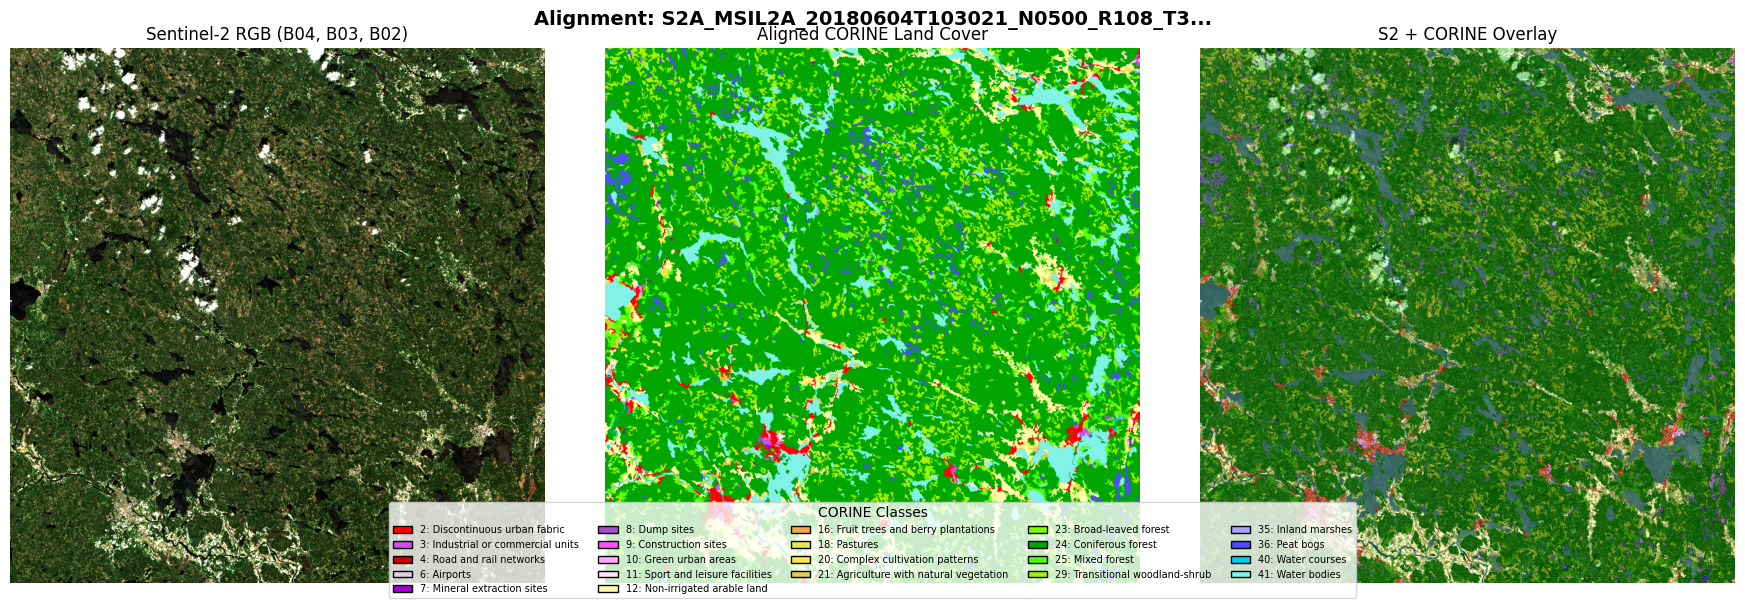


CORINE Classes in this tile:
  Class  2: Discontinuous urban fabric     - 1,783,363 pixels (1.5%)
  Class  3: Industrial or commercial units - 221,051 pixels (0.2%)
  Class  4: Road and rail networks         - 6,491 pixels (0.0%)
  Class  6: Airports                       - 34,575 pixels (0.0%)
  Class  7: Mineral extraction sites       - 54,661 pixels (0.0%)
  Class  8: Dump sites                     - 19,387 pixels (0.0%)
  Class  9: Construction sites             - 3,295 pixels (0.0%)
  Class 10: Green urban areas              - 49,814 pixels (0.0%)
  Class 11: Sport and leisure facilities   - 127,916 pixels (0.1%)
  Class 12: Non-irrigated arable land      - 7,197,020 pixels (6.0%)
  Class 16: Fruit trees and berry plantati - 3,002 pixels (0.0%)
  Class 18: Pastures                       - 180,700 pixels (0.1%)
  Class 20: Complex cultivation patterns   - 383,570 pixels (0.3%)
  Class 21: Agriculture with natural veget - 779,416 pixels (0.6%)
  Class 23: Broad-leaved forest       

In [15]:
# Visualize first (or other) successful result
successful_results = [r for r in all_results if r['status'] in ['success', 'skipped']]
aligned_pairs = find_aligned_pairs(OUTPUT_DIR)

if successful_results:
    result = successful_results[1] # Change to change which result is visualized
    tile_name = result['tile']
    
    # Create save path for the visualization
    save_path = Path(RESULTS_DIR) / f"alignment_{tile_name[:50]}.png"
    
    print(f"Visualizing: {tile_name[:50]}...")
    visualize_alignment(
        result['s2_stacked'], 
        result['corine_aligned'],
        title=f"Alignment: {tile_name[:40]}...",
        save_path=save_path
    )
else:
    print("No successful results to visualize.")

In [11]:
# Display detailed results
print("Detailed Results per Tile:")
print("-" * 90)
print(f"{'Tile':<50} {'Status':<15} {'Classes':<10} {'Coverage':<10}")
print("-" * 90)

for result in all_results:
    tile_short = result['tile'][:48] + ".." if len(result['tile']) > 50 else result['tile']
    coverage = f"{result['coverage_percent']:.1f}%" if result['coverage_percent'] > 0 else "-"
    classes = str(result['n_classes']) if result['n_classes'] > 0 else "-"
    print(f"{tile_short:<50} {result['status']:<15} {classes:<10} {coverage:<10}")

Detailed Results per Tile:
------------------------------------------------------------------------------------------
Tile                                               Status          Classes    Coverage  
------------------------------------------------------------------------------------------
S2A_MSIL2A_20180422T102031_N0500_R065_T33VWH_202.. skipped         22         100.0%    
S2A_MSIL2A_20180604T103021_N0500_R108_T33VWH_202.. skipped         22         100.0%    
S2B_MSIL2A_20180318T102019_N0500_R065_T33VWH_202.. skipped         22         100.0%    
S2B_MSIL2A_20180808T103019_N0500_R108_T33VWH_202.. skipped         22         100.0%    
